# RAGTruth Dataset Overview

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import os

## Load the dataset

In [9]:
baseline_dir = "../RAGTruth/baseline"

def load_jsonl(path):
    records = []
    with open(path, "r") as f:
        for line in f:
            records.append(json.loads(line))
    return records

train = load_jsonl(os.path.join(baseline_dir, "train.jsonl"))
dev   = load_jsonl(os.path.join(baseline_dir, "dev.jsonl"))
test  = load_jsonl(os.path.join(baseline_dir, "test.jsonl"))

print(f"Train: {len(train)}")
print(f"Dev:   {len(dev)}")
print(f"Test:  {len(test)}")

Train: 14047
Dev:   895
Test:  2675


## Split sizes

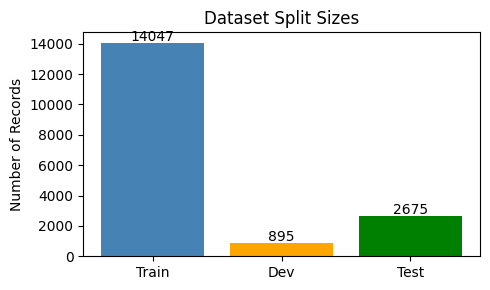

In [3]:
split_counts = {"Train": len(train), "Dev": len(dev), "Test": len(test)}
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(split_counts.keys(), split_counts.values(), color=["steelblue", "orange", "green"])
ax.set_title("Dataset Split Sizes")
ax.set_ylabel("Number of Records")
for i, (k, v) in enumerate(split_counts.items()):
    ax.text(i, v + 100, str(v), ha="center")
plt.tight_layout()
plt.show()

## Task type distribution

task_type
Data2txt    6195
QA          5767
Summary     5655
Name: count, dtype: int64


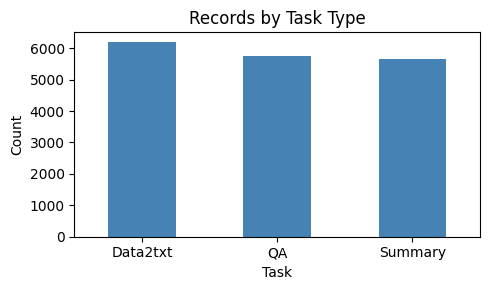

In [4]:
all_records = train + dev + test
df = pd.DataFrame(all_records)

task_counts = df["task_type"].value_counts()
print(task_counts)

fig, ax = plt.subplots(figsize=(5, 3))
task_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Records by Task Type")
ax.set_ylabel("Count")
ax.set_xlabel("Task")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## LLM distribution

model
llama-2-13b-chat       2959
llama-2-70b-chat       2958
llama-2-7b-chat        2946
gpt-4-0613             2937
mistral-7B-instruct    2911
gpt-3.5-turbo-0613     2906
Name: count, dtype: int64


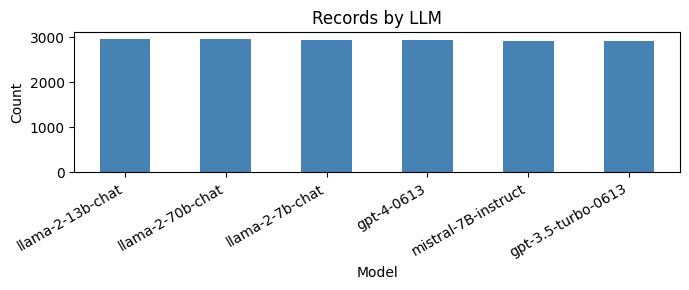

In [5]:
model_counts = df["model"].value_counts()
print(model_counts)

fig, ax = plt.subplots(figsize=(7, 3))
model_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Records by LLM")
ax.set_ylabel("Count")
ax.set_xlabel("Model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Hallucination rate

Hallucination rate by task:
task_type
Data2txt    0.686
QA          0.296
Summary     0.298
Name: has_hallucination, dtype: float64


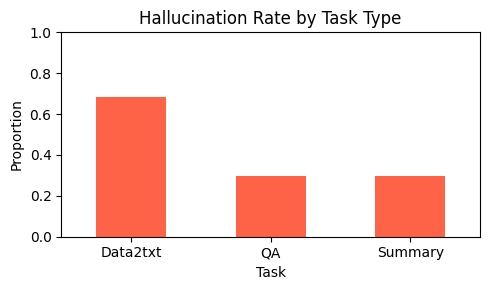

In [6]:
df["has_hallucination"] = df["labels"].apply(lambda x: len(x) > 0)

halu_rate = df.groupby("task_type")["has_hallucination"].mean().round(3)
print("Hallucination rate by task:")
print(halu_rate)

fig, ax = plt.subplots(figsize=(5, 3))
halu_rate.plot(kind="bar", ax=ax, color="tomato")
ax.set_title("Hallucination Rate by Task Type")
ax.set_ylabel("Proportion")
ax.set_xlabel("Task")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Hallucination label type breakdown

Evident Baseless Info    6205
Evident Conflict         5306
Subtle Baseless Info     2514
Subtle Conflict           201
Name: count, dtype: int64


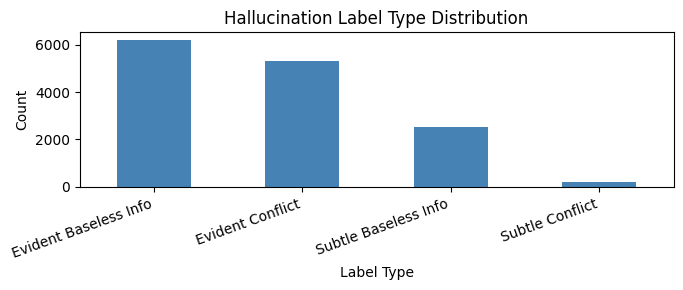

In [7]:
all_labels = []
for record in all_records:
    for lbl in record.get("labels", []):
        all_labels.append(lbl.get("label_type", "unknown"))

label_series = pd.Series(all_labels)
label_counts = label_series.value_counts()
print(label_counts)

fig, ax = plt.subplots(figsize=(7, 3))
label_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Hallucination Label Type Distribution")
ax.set_ylabel("Count")
ax.set_xlabel("Label Type")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Sample data cards

In [8]:
samples_with_halu = [r for r in test if len(r.get("labels", [])) > 0][:3]

for i, sample in enumerate(samples_with_halu):
    print(f"--- Sample {i+1} ---")
    print(f"Task:  {sample.get('task_type')}")
    print(f"Model: {sample.get('model')}")
    if sample.get("task_type") == "QA":
        print(f"Question: {sample.get('question', '')}")
    response = sample.get("response", "")
    print(f"Response (first 300 chars): {response[:300]}")
    print(f"Hallucinated spans:")
    for lbl in sample.get("labels", []):
        print(f"  [{lbl['label_type']}] '{lbl['text']}'")
    print()

--- Sample 1 ---
Task:  Summary
Model: llama-2-13b-chat
Response (first 300 chars): Three women, including Keonna Thomas of Philadelphia, were charged with attempting to join ISIS this week. Thomas purchased a ticket to Barcelona but was arrested before her trip. Two other women, Noelle Velentzas and Asia Siddiqui, were arrested in New York for planning to build an explosive device
Hallucinated spans:
  [Evident Conflict] 'Three women, including Keonna Thomas of Philadelphia, were charged with attempting to join ISIS this week.'
  [Evident Conflict] 'was arrested before her trip'

--- Sample 2 ---
Task:  Summary
Model: llama-2-70b-chat
Response (first 300 chars): A 30-year-old Philadelphia woman, Keonna Thomas, was charged with attempting to travel to Syria to join ISIS. She was arrested on March 26 and could face 15 years in prison. Two other women, Noelle Velentzas and Asia Siddiqui, were arrested in New York for planning to build an explosive device for a
Hallucinated spans:
  [Evid